# Libraries

In [540]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from scipy.interpolate import griddata #Contour plots
from matplotlib import rcParams

# Set global font to Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

In [541]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\K2SO4\20240531 - Ag60 GDE_0.3 M K2SO4_pH1

16-Aug-26  11:08 PM    <DIR>          .
07-Jun-26  07:23 PM    <DIR>          ..
29-Jul-26  07:26 AM    <DIR>          .ipynb_checkpoints
14-Jun-24  11:51 AM           641,506 0.3M Cs2SO4_pH1.xlsx
01-Jun-24  04:49 PM            12,905 0p3M_pH1 K2SO4_20240601_1448_5min.xlsx
01-Jun-24  04:49 PM            43,038 0p3M_pH1 K2SO4_20240601_1449_1min - Copy.xlsx
29-Jul-26  12:23 PM            57,006 0p3M_pH1 K2SO4_20240601_1449_1min.xlsx
01-Jun-24  04:49 PM           347,516 0p3M_pH1 K2SO4_20240601_1449_Line_1.csv
16-Aug-26  11:05 PM           736,460 20240531 - Ag60 GDE_0.3 M K2SO4_pH1 - CORRECTED.ipynb
29-Jul-26  07:25 AM           531,390 20240531 - Ag60 GDE_0.3 M K2SO4_pH1 - CORRECTED-Copy1.ipynb
12-May-25  11:29 AM           794,334 20240531 - Ag60 GDE_0.3 M K2SO4_pH1.ipynb
16-Aug-26  11:03 PM              

# Load Data

In [542]:
Book = "Book_20240531 - Ag60 GDE_0.3 M K2SO4_pH1.xlsx"
Book = pd.read_excel(Book)
Book.head(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(H2),c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24
0,Ag60 GDE in PTFE holder,60,58.193241,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-05-31 18:56:37.424,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.0000
1,Ag60 GDE in PTFE holder,60,59.620423,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-05-31 19:09:11.000,0.209327,1.264142,...,0.012397,0.000046,0.987086,0.000457,0.914248,0.003405,NaN,0.917653,0.000047,NaN
2,Ag60 GDE in PTFE holder,60,59.983401,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-05-31 19:31:41.000,0.584327,1.241393,...,0.012223,0.000043,0.987309,0.000411,0.906898,0.003220,NaN,0.910117,0.000044,100.2774


In [543]:
Book["Duration / h"] = round(Book["Duration / h"],2)
Book["Flow rate (ml min-1)"] = round(Book["Flow rate (ml min-1)"],2)
# Flow_df = Book[["Time", "Duration / h", "Flow rate (ml min-1)"]].copy()
Book["GC_flow_rate_ml_min"] = Book["Flow rate (ml min-1)"]
Book.tail(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min
60,Ag60 GDE in PTFE holder,60,70.73,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-06-01 13:53:30,18.95,15.710301,...,0.001282,0.844683,0.001142,2.862184,0.023995,NaN,2.886179,0.001515,86.9326,70.73
61,Ag60 GDE in PTFE holder,60,70.81,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-06-01 14:08:31,19.20,15.720136,...,0.001210,0.844566,0.001166,2.868603,0.022679,NaN,2.891282,0.001431,NaN,70.81
62,Ag60 GDE in PTFE holder,60,70.99,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-06-01 14:23:32,19.45,15.695609,...,0.001271,0.844192,0.001126,2.867965,0.023887,NaN,2.891852,0.001503,86.9486,70.99


### Temp from pH

In [544]:
Temp = "2024-06-01_141547.csv"
Temp = pd.read_csv(Temp)
Temp[["Supp Reading 1", "Supp Units 1"]]
Temp_C_mean = Temp["Supp Reading 1"].mean()
Temp_C_median = Temp["Supp Reading 1"].median()

print("Temp C mean:", Temp_C_mean)
print("Temp C median:", Temp_C_median)

Temp C mean: 25.442727272727275
Temp C median: 24.6


### Power Supply

In [545]:
power_sup = "Power supply_1.csv"
power_sup = pd.read_csv(power_sup, sep=";")
power_sup.head(2)

,U set,U actual,I set,I actual,P set,P actual,R set,R actual,R mode,Output/Input,Device mode,Error,Time
0,0.00V,0.24V,0.000A,0.000A,320.00W,0.00W,NaN,NaN,NaN,On,CV,NaN,31.05.2024 18:56:37.424
1,40.00V,1.76V,0.100A,0.099A,320.00W,0.00W,NaN,NaN,NaN,On,CC,NaN,31.05.2024 18:56:42.416


In [546]:
power_sup.groupby("I set", group_keys=True)[['U actual']].apply(lambda x: x).head(3)

U actual
I set                
0.000A 0        0.24V
       15741    2.36V
       15743    1.90V

In [547]:
power_sup["Time"] = pd.to_datetime(
    power_sup["Time"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

power_sup["I actual"] = (
    power_sup["I actual"]
    .str.replace("A", "", regex=False)
    .str.strip()
    .astype(float)
)
power_sup["U actual"] = (
    power_sup["U actual"]
    .str.replace("V", "", regex=False)
    .str.strip()
    .astype(float)
)

# Set time as index
power_sup = power_sup.set_index("Time")

# Mean current and voltage every 2 hours
power_summary = (
    power_sup.resample("2h")
    .agg({
        "I actual": "median",
        "U actual": "median"
    })
    .reset_index()
)

# Rename column
# I_mean = I_mean.rename(columns={"I actual": "I actual_mean (A)"})
print(power_summary)

                  Time  I actual  U actual
0  2024-05-31 18:00:00    0.0990      2.43
1  2024-05-31 20:00:00    0.2520      2.98
2  2024-05-31 22:00:00    0.4990      3.77
3  2024-06-01 00:00:00    0.7440      4.31
4  2024-06-01 02:00:00    0.9935      4.85
5  2024-06-01 04:00:00    1.4910      5.64
6  2024-06-01 06:00:00    1.9820      6.61
7  2024-06-01 08:00:00    2.9840      8.22
8  2024-06-01 10:00:00    1.4970      6.05
9  2024-06-01 12:00:00    1.4950      5.93
10 2024-06-01 14:00:00    1.4950      6.01
11 2024-06-01 16:00:00    1.4950      6.01


In [548]:
# cell_voltage = power_summary.iloc[3:].reset_index(drop=True) #Power supply was recording before the experiment
# power_summary.loc[power_summary.index[0], "I actual"] = 0 #The first row will be taken is 0, not current was input
power_summary = power_summary.iloc[:-4].reset_index(drop=True) #after 16h
print(power_summary)

                 Time  I actual  U actual
0 2024-05-31 18:00:00    0.0990      2.43
1 2024-05-31 20:00:00    0.2520      2.98
2 2024-05-31 22:00:00    0.4990      3.77
3 2024-06-01 00:00:00    0.7440      4.31
4 2024-06-01 02:00:00    0.9935      4.85
5 2024-06-01 04:00:00    1.4910      5.64
6 2024-06-01 06:00:00    1.9820      6.61
7 2024-06-01 08:00:00    2.9840      8.22


In [549]:
dfcell_voltage = pd.DataFrame(power_summary)
dfcell_voltage = dfcell_voltage.rename(columns={"U actual": "Voltage"})
dfcell_voltage = dfcell_voltage.set_index("I actual")
dfcell_voltage = dfcell_voltage.drop(columns=["Time"])
dfcell_voltage

,Voltage
I actual,
0.0990,2.43
0.2520,2.98
0.4990,3.77
0.7440,4.31
0.9935,4.85
1.4910,5.64
1.9820,6.61
2.9840,8.22


In [550]:
dfcell_voltage["Current Density [mA cm-2]"] = dfcell_voltage.index*10
dfcell_voltage

,Voltage,Current Density [mA cm-2]
I actual,,
0.0990,2.43,0.990
0.2520,2.98,2.520
0.4990,3.77,4.990
0.7440,4.31,7.440
0.9935,4.85,9.935
1.4910,5.64,14.910
1.9820,6.61,19.820
2.9840,8.22,29.840


## Flow rate

In [601]:
flow_rate = "0p3M_pH1 K2SO4_20240601_1449_1min.xlsx"
flow_rate = pd.read_excel(flow_rate, sheet_name="Process data")
flow_rate.head(20)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Report generated (UTC),2024-06-01 14:49:01.200000,NaN
1,Software version,Aurora 1.0.2,NaN
2,Instrument name,0p3M_pH1 K2SO4,NaN
3,Instrument model name,BPC Go,NaN
4,Ethernet mac address,f8:dc:7a:6e:f2:c4,NaN
5,Agitation state,Off,NaN
6,Agitation phase,Single,NaN
7,Agitation phase speed (%),30,NaN
8,Gas normalisation,Unnormalised,NaN
9,NaN,NaN,NaN


In [602]:
flow_rate = flow_rate.iloc[18:].reset_index(drop=True)
flow_rate = flow_rate.rename(columns={
    "Unnamed: 0": "Time (UTC)",
    "Unnamed: 1": "Gas flow rate [ml/min]",
    "Unnamed: 2": "Specific gas production [ml/min/l]"
})
flow_rate.head(10)

,Time (UTC),Gas flow rate [ml/min],Specific gas production [ml/min/l]
0,2024-05-31 16:56:00.038000,58.193241,29.096621
1,2024-05-31 16:57:00,59.351417,29.675708
2,2024-05-31 16:57:59.962000,59.851802,29.925901
3,2024-05-31 16:59:00.010000,59.571481,29.78574
4,2024-05-31 16:59:59.971000,59.522173,29.761086
5,2024-05-31 17:01:00.019000,59.605997,29.802998
6,2024-05-31 17:01:59.981000,59.808338,29.904169
7,2024-05-31 17:03:00.029000,59.772887,29.886443
8,2024-05-31 17:03:59.990000,59.614531,29.807266
9,2024-05-31 17:05:00.038000,60.011032,30.005516


In [603]:
flow_rate["Time (UTC)"] = pd.to_datetime(
    flow_rate["Time (UTC)"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

# Set time as index
flow_rate = flow_rate.set_index("Time (UTC)")

# Mean current and voltage every 2 hours
flow_rate = (
    flow_rate.resample("2h")
    .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"), 
         Flow_rate_max=("Gas flow rate [ml/min]", "max"),
         Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
         Flow_rate_median=("Gas flow rate [ml/min]", "median"))
    .reset_index()
)

print(flow_rate)

            Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0  2024-05-31 16:00:00     58.193241      60.38345      59.857437   
1  2024-05-31 18:00:00      59.92051     62.430681      61.204539   
2  2024-05-31 20:00:00     61.419971     64.673419      63.081708   
3  2024-05-31 22:00:00     63.330253     66.632513      64.951348   
4  2024-06-01 00:00:00     65.341915     68.778062      67.078331   
5  2024-06-01 02:00:00     67.228402     73.561732      70.412669   
6  2024-06-01 04:00:00     71.320743     76.257435       73.73998   
7  2024-06-01 06:00:00     74.587575     81.099188      77.716513   
8  2024-06-01 08:00:00      67.70041     80.176878      74.143266   
9  2024-06-01 10:00:00     70.021995     71.202261      70.664647   
10 2024-06-01 12:00:00     70.474421     71.321116       70.94936   
11 2024-06-01 14:00:00     51.930776     71.335281      70.453775   

   Flow_rate_median  
0         59.893787  
1         61.713379  
2         63.806862  
3         65.7

### COrrection for dry flow

In [604]:
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
T   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
P   = 101325       # pressure                           [Pa]
V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- wet-to-dry correction ----
# The flow meter reads the wet gas leaving the cell. Assuming saturation at the
# meter temperature, water occupies x_H2O of the stream; the remaining fraction
# is product + carrier. p_sat from the Buck equation.
T_C   = Temp_C_median
P_SAT = 0.61121*np.exp((18.678 - T_C/234.5)*(T_C/(257.14 + T_C))) * 1000   # Pa
X_H2O = P_SAT / P                  # 0.0282 at 23.3 degC
DRY   = 1 - X_H2O                  # 0.9718

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]

print(f"V_m   = {V_m:.3f} L/mol")
print(f"p_sat = {P_SAT/1000:.4f} kPa -> x(H2O) = {X_H2O*100:.2f} % -> dry factor {DRY:.5f}")

V_m   = 24.431 L/mol
p_sat = 3.0938 kPa -> x(H2O) = 3.05 % -> dry factor 0.96947


In [605]:
FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]
for c in FLOW_COLS:
    flow_rate[c + "_dry"] = flow_rate[c] * DRY

# FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]

# for c in FLOW_COLS:
#     flow_rate[c + "_corr"] = flow_rate[c] * 0.9723

# flow_rate

In [606]:
print(flow_rate)

            Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0  2024-05-31 16:00:00     58.193241      60.38345      59.857437   
1  2024-05-31 18:00:00      59.92051     62.430681      61.204539   
2  2024-05-31 20:00:00     61.419971     64.673419      63.081708   
3  2024-05-31 22:00:00     63.330253     66.632513      64.951348   
4  2024-06-01 00:00:00     65.341915     68.778062      67.078331   
5  2024-06-01 02:00:00     67.228402     73.561732      70.412669   
6  2024-06-01 04:00:00     71.320743     76.257435       73.73998   
7  2024-06-01 06:00:00     74.587575     81.099188      77.716513   
8  2024-06-01 08:00:00      67.70041     80.176878      74.143266   
9  2024-06-01 10:00:00     70.021995     71.202261      70.664647   
10 2024-06-01 12:00:00     70.474421     71.321116       70.94936   
11 2024-06-01 14:00:00     51.930776     71.335281      70.453775   

   Flow_rate_median Flow_rate_min_dry Flow_rate_max_dry Flow_rate_mean_dry  \
0         59.893787     

In [607]:
dfflow_rate = pd.DataFrame(flow_rate)
dfflow_rate['Current [A]'] = power_summary['I actual']
dfflow_rate['Voltage'] = power_summary['U actual']
dfflow_rate = dfflow_rate.iloc[:-4].reset_index(drop=True)
dfflow_rate

,Time (UTC),Flow_rate_min,Flow_rate_max,Flow_rate_mean,Flow_rate_median,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_mean_dry,Flow_rate_median_dry,Current [A],Voltage
0,2024-05-31 16:00:00,58.193241,60.38345,59.857437,59.893787,56.416425,58.539761,58.029809,58.065048,0.0990,2.43
1,2024-05-31 18:00:00,59.92051,62.430681,61.204539,61.713379,58.090956,60.524484,59.335779,59.829083,0.2520,2.98
2,2024-05-31 20:00:00,61.419971,64.673419,63.081708,63.806862,59.544634,62.698744,61.155633,61.858646,0.4990,3.77
3,2024-05-31 22:00:00,63.330253,66.632513,64.951348,65.798048,61.396589,64.598021,62.968186,63.789035,0.7440,4.31
4,2024-06-01 00:00:00,65.341915,68.778062,67.078331,67.800366,63.346829,66.67806,65.030227,65.730216,0.9935,4.85
5,2024-06-01 02:00:00,67.228402,73.561732,70.412669,72.031142,65.175716,71.31567,68.262757,69.831813,1.4910,5.64
6,2024-06-01 04:00:00,71.320743,76.257435,73.73998,74.91806,69.143105,73.929065,71.488475,72.630586,1.9820,6.61
7,2024-06-01 06:00:00,74.587575,81.099188,77.716513,79.620071,72.310191,78.622985,75.343593,77.189029,2.9840,8.22


In [610]:
# dfflow_rate.to_csv('20240531_0.3M K2SO4_pH1_flow rate.csv')

## Energy consumption

Units: cm2 to m2: 1000cm2 is 1m2.  <br>
mA to A: 1000mA is 1A.  <br>
hrs to sec: 1hr is 3600 <br>
10cm2 = 0.001m2. <br> 2hr = 7200 <br>
1Wh = 3600J

*Energy consumption* = Current density [A cm2]* time [s] * cell voltage [V] * area of the electrode [m2]

In [628]:
electrode_area = 10/10000 #10cm2 to m2
time = 2*3600 #2hrs

dfcell_voltage["Current Density [A m-2]"] = dfcell_voltage["Current Density [mA cm-2]"]*100000/1000
dfcell_voltage.head(3)

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I actual,,,,,
0.099,2.43,0.99,99.0,1732.104,0.000481
0.252,2.98,2.52,252.0,5406.912,0.001502
0.499,3.77,4.99,499.0,13544.856,0.003762


In [629]:
dfcell_voltage["Energy Consumption [J]"] = dfcell_voltage.index * time * dfcell_voltage["Voltage"]
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I actual,,,,,
0.0990,2.43,0.990,99.0,1732.104,0.000481
0.2520,2.98,2.520,252.0,5406.912,0.001502
0.4990,3.77,4.990,499.0,13544.856,0.003762
0.7440,4.31,7.440,744.0,23087.808,0.006413
0.9935,4.85,9.935,993.5,34693.020,0.009637
1.4910,5.64,14.910,1491.0,60546.528,0.016818
1.9820,6.61,19.820,1982.0,94327.344,0.026202
2.9840,8.22,29.840,2984.0,176605.056,0.049057


In [630]:
dfcell_voltage["Energy Consumption [kWh]"] = dfcell_voltage["Energy Consumption [J]"]/3600000 #1kWh is 3.6xe6 joules
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I actual,,,,,
0.0990,2.43,0.990,99.0,1732.104,0.000481
0.2520,2.98,2.520,252.0,5406.912,0.001502
0.4990,3.77,4.990,499.0,13544.856,0.003762
0.7440,4.31,7.440,744.0,23087.808,0.006413
0.9935,4.85,9.935,993.5,34693.020,0.009637
1.4910,5.64,14.910,1491.0,60546.528,0.016818
1.9820,6.61,19.820,1982.0,94327.344,0.026202
2.9840,8.22,29.840,2984.0,176605.056,0.049057


In [633]:
# dfcell_voltage.to_csv('20240531_0.3 M K2SO4_pH1_Energy Consumption.csv')

## FE(CO) and FE(H2)

## Integer Duration ("Applied Current /A" - Values optimization)

In [634]:
Book['Integer Duration'] = np.floor(Book['Duration / h'])
Book = Book[Book['Integer Duration'] < 16].copy()
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration,Current Density
0,Ag60 GDE in PTFE holder,60,58.19,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-05-31 18:56:37.424,0.00,0.000000,...,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.0000,58.19,0.0,0.0
1,Ag60 GDE in PTFE holder,60,59.62,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-05-31 19:09:11.000,0.21,1.264142,...,0.000457,0.914248,0.003405,NaN,0.917653,0.000047,NaN,59.62,0.0,-107.0
2,Ag60 GDE in PTFE holder,60,59.98,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-05-31 19:31:41.000,0.58,1.241393,...,0.000411,0.906898,0.003220,NaN,0.910117,0.000044,100.2774,59.98,0.0,-107.0
3,Ag60 GDE in PTFE holder,60,59.85,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-05-31 19:54:13.000,0.96,1.250440,...,0.000388,0.909356,0.002228,NaN,0.911584,0.000031,NaN,59.85,0.0,-107.0
4,Ag60 GDE in PTFE holder,60,60.21,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-05-31 20:16:45.000,1.34,1.244810,...,0.000389,0.911609,0.002476,NaN,0.914084,0.000034,100.4084,60.21,1.0,-107.0
5,Ag60 GDE in PTFE holder,60,60.20,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-05-31 20:39:18.000,1.71,1.236581,...,0.000392,0.905648,0.002303,NaN,0.907951,0.000031,NaN,60.20,1.0,-107.0
6,Ag60 GDE in PTFE holder,60,62.33,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-31 21:01:48.000,2.09,2.022076,...,0.000371,0.606336,0.000914,NaN,0.607250,0.000030,99.8324,62.33,2.0,-270.0
7,Ag60 GDE in PTFE holder,60,61.90,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-31 21:24:19.000,2.46,3.195131,...,0.000372,0.950389,0.000746,NaN,0.951135,0.000025,NaN,61.90,2.0,-270.0
8,Ag60 GDE in PTFE holder,60,62.30,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-31 21:46:51.000,2.84,3.212811,...,0.000387,0.960976,0.000754,NaN,0.961730,0.000025,98.7337,62.30,2.0,-270.0
9,Ag60 GDE in PTFE holder,60,61.70,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-31 22:19:52.000,3.39,3.221966,...,0.000365,0.954911,0.000864,NaN,0.955775,0.000029,NaN,61.70,3.0,-270.0


## Current Density

In [635]:
Book["Current Density"] = (Book['Applied current / A']/10)*10000 #mA
Book.head(5)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration,Current Density
0,Ag60 GDE in PTFE holder,60,58.19,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-05-31 18:56:37.424,0.00,0.000000,...,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.0000,58.19,0.0,0.0
1,Ag60 GDE in PTFE holder,60,59.62,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-05-31 19:09:11.000,0.21,1.264142,...,0.000457,0.914248,0.003405,NaN,0.917653,0.000047,NaN,59.62,0.0,-107.0
2,Ag60 GDE in PTFE holder,60,59.98,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-05-31 19:31:41.000,0.58,1.241393,...,0.000411,0.906898,0.003220,NaN,0.910117,0.000044,100.2774,59.98,0.0,-107.0
3,Ag60 GDE in PTFE holder,60,59.85,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-05-31 19:54:13.000,0.96,1.250440,...,0.000388,0.909356,0.002228,NaN,0.911584,0.000031,NaN,59.85,0.0,-107.0
4,Ag60 GDE in PTFE holder,60,60.21,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-05-31 20:16:45.000,1.34,1.244810,...,0.000389,0.911609,0.002476,NaN,0.914084,0.000034,100.4084,60.21,1.0,-107.0


In [636]:
Book["area(CO2)"]

0       0.000000
1     100.653906
2     100.272969
3     100.503645
4     100.405024
5     100.388983
6      99.829426
7      98.769459
8      98.731156
9      98.780729
10     98.737270
11     96.981071
12     96.310175
13     96.310175
14     96.295963
15     96.167499
16     96.194821
17     96.205021
18     93.766184
19     93.548624
20     93.686355
21     93.617578
22     93.189852
23     91.324103
24     91.271636
25     91.173051
26     91.182983
27     91.152074
28     87.189067
29     86.883030
30     86.811002
31     86.744782
32     86.702395
33     86.633328
34     86.535245
35     83.246536
36     82.529452
37     82.487876
38     82.353334
39     82.357510
40     82.341825
41     82.440248
42     78.284264
43     75.390974
44     75.014609
45     74.891373
46     74.725468
47     74.881292
48     74.819014
49     74.819519
Name: area(CO2), dtype: float64

## FE(CO)

In [637]:
# Book["FE(CO)"] = Book["c(CO)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"] as in excell

In [638]:
# # ---- physical constants ----
# F   = 96485        # Faraday constant                   [C/mol]
# R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
# T   = 296.15       # gas temperature at the meter       [K]  (~23 degC)
# P   = 101325       # pressure                           [Pa]
# V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]
print(f"V_m = {V_m:.3f} L/mol")

V_m = 24.431 L/mol


In [639]:
currents     = [i for i in dfcell_voltage.index.to_list() if i != 0]
currents

[0.099, 0.252, 0.499, 0.744, 0.9935, 1.491, 1.982, 2.984]

In [640]:
# Determine the 2 h step for each GC injection
step = (Book["Duration / h"] // 2).astype(int)

# Count injections per step
inj_per_step = step.value_counts().sort_index().tolist()
inj_per_step

[6, 5, 6, 5, 6, 7, 7, 8]

In [641]:
currents # The actual applied current from the power supply file (without the first 0)   # GC injections per step (estimate). From Book excel
inj_per_step # GC injections per step (2h)

I_seq = np.repeat(currents, inj_per_step)
# rows  = Book.iloc[first_row : first_row + len(I_seq)].copy().reset_index(drop=True)
rows = Book.iloc[:len(I_seq)].copy().reset_index(drop=True)
rows["Current_abs"] = rows["Applied current / A"].abs()

rows = rows.sort_values("Current_abs")
dfflow_rate = dfflow_rate.sort_values("Current [A]")

rows = pd.merge_asof(
    rows,
    dfflow_rate[["Current [A]", "Flow_rate_mean_dry", "Flow_rate_min_dry", "Flow_rate_max_dry", "Flow_rate_median_dry"]],
    left_on="Current_abs",
    right_on="Current [A]",
    direction="nearest"
)
# Clean columns
# rows = rows.drop(columns=["Current_abs", "Current [A]"])

rows["Applied current / A"] = -I_seq                    # cathodic -> negative
rows["Current Density"]     = rows["Applied current / A"] / 10 * 10000   # mA cm-2 10 is A_cm2 electrode

# check: c(H2) should rise monotonically from one step to the next
print(rows.groupby(rows["Applied current / A"].abs())[["c(H2)", "c(CO)"]].median().round(3))
# rows[["c(H2)", "c(CO)","FE(H2)", "FE(CO)"]].head(50)

                     c(H2)  c(CO)
Applied current / A              
0.0990               0.012  0.000
0.2520               0.031  0.000
0.4990               0.058  0.000
0.7440               0.083  0.000
0.9935               0.107  0.000
1.4910               0.151  0.000
1.9820               0.186  0.008
2.9840               0.230  0.039


In [642]:
# def faradaic_efficiency(conc, flow_ml_min, current_A):
#     flow_L_s    = flow_ml_min / 1000 / 60     # mL/min -> L/s
#     mol_per_s   = conc * flow_L_s / V_m         # mol of this gas per second
#     charge_rate = mol_per_s * n_e * F           # current carried by this gas [A]
#     return charge_rate / current_A.abs() * 100  # %

def faradaic_efficiency(conc, flow_ml_min, current_A, n_electrons):
    gas_volume_ml_min = conc * flow_ml_min #Concentration in molar_fraction × flow_total = vol gas
    gas_volume_L_s = gas_volume_ml_min / 1000 / 60 #ml/min → L/s
    mol_per_s = gas_volume_L_s / V_m #volume → molar flow using V_m (Ideal gas law)
    charge_rate = mol_per_s * n_electrons * F # moles to amp. Each molecule carries z electrons
    FE = (charge_rate / abs(current_A)) * 100
    return FE


# rows["FE(CO)"] = faradaic_efficiency(
#     rows["c(CO)"], 
#     rows["Flow_rate_min"], 
#     rows["Current [A]"], 2)

# rows["FE(H2)"] = faradaic_efficiency(
#     rows["c(H2)"], 
#     rows["Flow_rate_min"], 
#     rows["Current [A]"], 2)

rows["FE(CO)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(CO)"], 
        row["Flow_rate_median_dry"],    # 2h period
        row["Current [A]"], 
        2
    ), 
    axis=1
)

rows["FE(H2)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(H2)"], 
        row["Flow_rate_median_dry"], 
        row["Current [A]"], 
        2
    ), 
    axis=1
)

# rows.loc[rows.index[0], "FE(H2)"] = 0
rows["FE(total)"] = rows["FE(H2)"] + rows["FE(CO)"]

# rows[["Current Density", "FE(H2)", "FE(CO)", "FE(total)"]].head(15)

# sanity check: H2 + CO must stay around / below 100 %
_tot = rows["FE(H2)"] + rows["FE(CO)"]
print(f"FE_total  min/max/mean = {_tot.min():.1f} / {_tot.max():.1f} / {_tot.mean():.1f} %")

FE_total  min/max/mean = 0.0 / 98.8 / 89.7 %


In [643]:
rows[rows["FE(H2)"]>100 ]

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)


In [644]:
# rows = rows.drop(rows[rows['FE(total)'] > 108].index) #Noise in the first measurements
# rows

In [645]:
# rows[rows["FE(total)"]>100 ]

### Mean FE per current density

In [646]:
summary = (
    rows.groupby(rows["Current Density"].abs().round(3).astype(int))
    .agg(
        # Faradaic efficiencies
        FE_H2_mean=("FE(H2)", "mean"),
        FE_CO_mean=("FE(CO)", "mean"),
        FE_H2_median=("FE(H2)", "median"),
        FE_CO_median=("FE(CO)", "median"),

        area_CO2_median=("area(CO2)", "median"),

        FE_H2_sem=("FE(H2)", "sem"),
        FE_CO_sem=("FE(CO)", "sem"),
        FE_H2_std=("FE(H2)", "std"),
        FE_CO_std=("FE(CO)", "std"),

        # IQR values for H2 and CO (median error bars)
        FE_H2_q25=("FE(H2)", lambda x: x.quantile(0.25)),
        FE_H2_q75=("FE(H2)", lambda x: x.quantile(0.75)),
        FE_CO_q25=("FE(CO)", lambda x: x.quantile(0.25)),
        FE_CO_q75=("FE(CO)", lambda x: x.quantile(0.75)),

        # Total FE statistics
        FE_total_mean=("FE(total)", "mean"),
        FE_total_median=("FE(total)", "median"),
        FE_total_sem=("FE(total)", "sem"),
        FE_total_std=("FE(total)", "std"),
        FE_total_q25=("FE(total)", lambda x: x.quantile(0.25)),
        FE_total_q75=("FE(total)", lambda x: x.quantile(0.75)),

        # Flow rate
        Flow_rate_min=("Flow rate (ml min-1)", "min"),
        Flow_rate_max=("Flow rate (ml min-1)", "max"),
        Flow_rate_mean=("Flow rate (ml min-1)", "mean"),
        Flow_rate_median=("Flow rate (ml min-1)", "median"),

        # CO concentration
        c_CO_min=("c(CO)", "min"),
        c_CO_max=("c(CO)", "max"),
        c_CO_mean=("c(CO)", "mean"),
        c_CO_median=("c(CO)", "median"),

        # H2 concentration
        c_H2_min=("c(H2)", "min"),
        c_H2_max=("c(H2)", "max"),
        c_H2_mean=("c(H2)", "mean"),
        c_H2_median=("c(H2)", "median"),

        # Number of measurements
        n=("FE(H2)", "size")
    )
    .reset_index()
    .rename(columns={"Current Density": "J (A m-2)"})
)

# Error bars for median (IQR)
summary["FE_H2_err_low"] = (
    summary["FE_H2_median"] - summary["FE_H2_q25"]
)
summary["FE_H2_err_high"] = (
    summary["FE_H2_q75"] - summary["FE_H2_median"]
)

summary["FE_CO_err_low"] = (
    summary["FE_CO_median"] - summary["FE_CO_q25"]
)
summary["FE_CO_err_high"] = (
    summary["FE_CO_q75"] - summary["FE_CO_median"]
)

summary["FE_total_err_low"] = (
    summary["FE_total_median"] - summary["FE_total_q25"]
)
summary["FE_total_err_high"] = (
    summary["FE_total_q75"] - summary["FE_total_median"]
)

# Experimental time intervals
summary["Time Interval (h)"] = [
    "0–2", "2–4", "4–6", "6–8",
    "8–10", "10–12", "12–14", "14–16"
]

print(summary)

   J (A m-2)  FE_H2_mean  FE_CO_mean  FE_H2_median  FE_CO_median  \
0         99   78.892019    0.236572     94.442241      0.247735   
1        252   91.137200    0.084336     98.346968      0.084936   
2        499   91.348438    0.033882     93.848953      0.034391   
3        744   88.166408    0.020900     93.858555      0.014945   
4        993   90.424725    0.008904     93.123797      0.008794   
5       1491   92.609670    0.047369     92.914704      0.042575   
6       1982   89.004865    3.671928     89.650932      3.627057   
7       2984   77.462622   12.848017     78.445054     13.243103   

   area_CO2_median  FE_H2_sem  FE_CO_sem  FE_H2_std  FE_CO_std  ...  \
0       100.397004  15.780327   0.051793  38.653749   0.126866  ...   
1        98.769459   7.279985   0.003284  16.278541   0.007343  ...   
2        96.303069   2.760235   0.002506   6.761168   0.006138  ...   
3        93.686355   5.630737   0.004323  12.590711   0.009666  ...   
4        91.227310   2.795809   

In [647]:
# print(rows[["c(CO)", "c(H2)", "Flow_rate_min", "Current [A]"]].head(7))

## FE(H2)

In [648]:
# Book["FE(H2)"] = Book["c(H2)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]
print(rows["FE(H2)"])
# Book
# print(rows["c(H2)"].describe())

0      0.000000
1     95.717920
2     94.373832
3     94.841351
4     94.510650
5     93.908363
6     62.023420
7     97.896558
8     98.346968
9     98.682555
10    98.736499
11    94.583969
12    94.598443
13    94.062479
14    93.635426
15    77.574935
16    93.635374
17    65.651165
18    93.262281
19    93.858555
20    93.896887
21    94.163153
22    93.585585
23    93.664855
24    93.279565
25    92.968029
26    92.580553
27    76.469764
28    90.292048
29    91.998630
30    92.389983
31    92.914704
32    93.271381
33    93.549451
34    93.851495
35    90.361405
36    90.190227
37    89.932216
38    88.940414
39    88.351005
40    85.607855
41    89.650932
42    79.417948
43    71.206513
44    76.249614
45    77.331433
46    78.161922
47    78.728185
48    78.987567
49    79.617794
Name: FE(H2), dtype: float64


# Plots

## Current Density vs Time

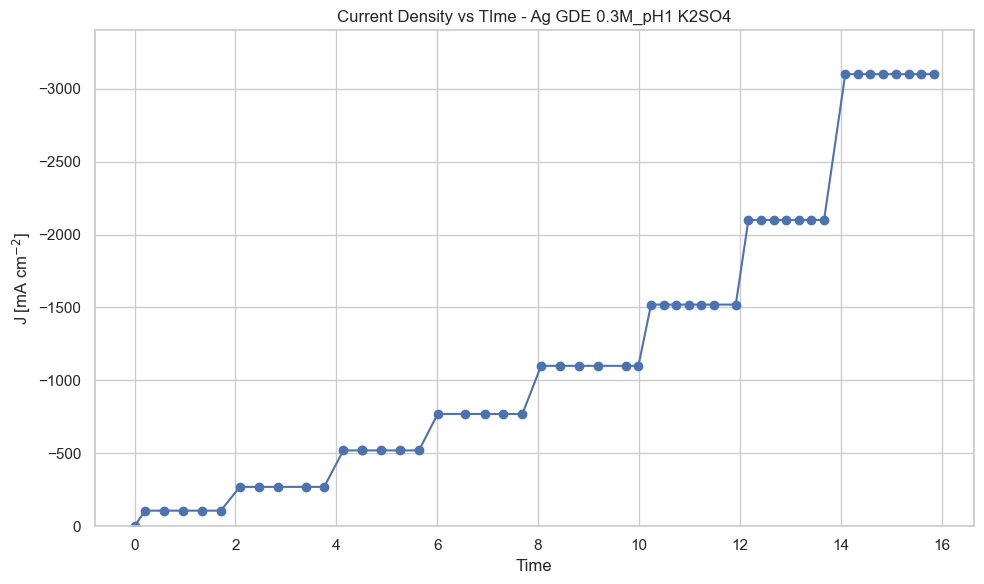

In [649]:
plt.figure(figsize=(10, 6)) 
plt.plot(Book["Duration / h"], Book['Current Density'], marker='o')  

plt.title('Current Density vs TIme - Ag GDE 0.3M_pH1 K2SO4')  
plt.xlabel('Time') 
plt.ylabel(r'J [mA cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0,-3400)
# plt.gca().set_xticklabels([])
# plt.xticks([])
plt.tight_layout()

plt.show()

## Current Density vs Flow Rate

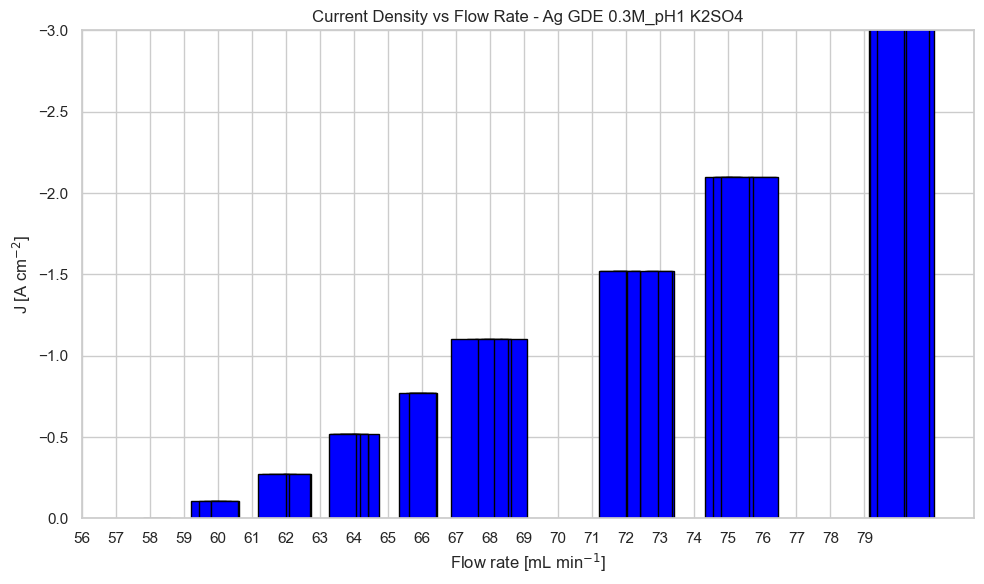

In [650]:
plt.figure(figsize=(10, 6)) 
plt.bar(Book["Flow rate (ml min-1)"], Book['Applied current / A'], color='blue', edgecolor='black')
plt.title('Current Density vs Flow Rate - Ag GDE 0.3M_pH1 K2SO4')  
plt.xlabel(r'Flow rate [mL min$^{-1}$]') 
plt.ylabel(r'J [A cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0, -3)
# plt.gca().set_xticklabels([])
plt.xticks(range(56,80,1))
plt.tight_layout()

plt.show()

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


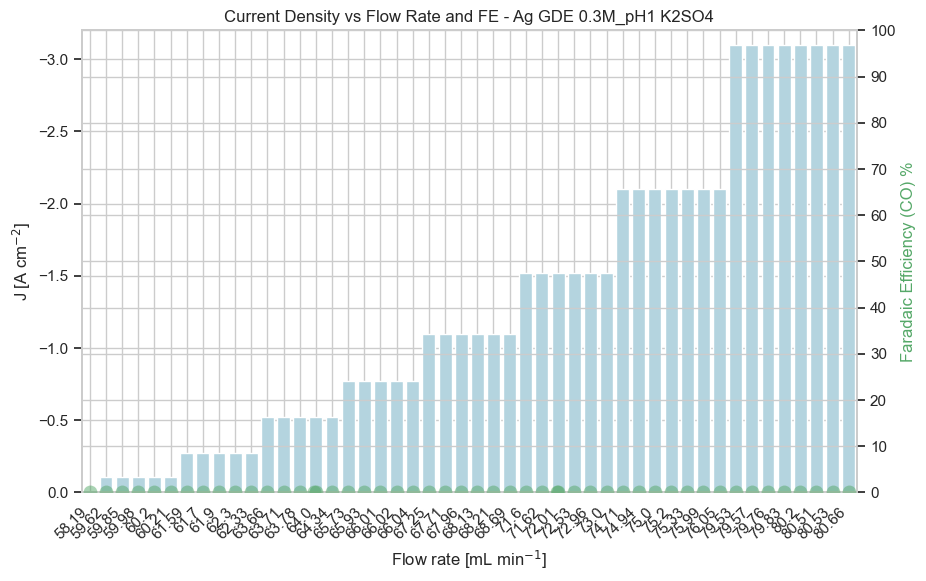

In [651]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis

sns.barplot(data=Book, x='Flow rate (ml min-1)', y='Applied current / A', ax=ax1, color='lightblue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Flow Rate and FE - Ag GDE 0.3M_pH1 K2SO4')
ax1.set_xlabel(r'Flow rate [mL min$^{-1}$]')
ax1.set_ylabel(r'J [A cm$^{-2}$]')
ax1.set_ylim(0, -3.2)
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=Book, x='Flow rate (ml min-1)',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=.5, legend=False, color='g')

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color='g')
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))

# plt.savefig('20240531_Ag_GDE_0_3M_pH1_CD_FL_FE_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [652]:
# g = sns.JointGrid(data=Book, x='Flow rate (ml min-1)',  y='Applied current / A', hue = 'FE(CO)')
# g.plot(sns.histplot, sns.kdeplot)

In [653]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\K2SO4\20240531 - Ag60 GDE_0.3 M K2SO4_pH1

16-Aug-26  11:10 PM    <DIR>          .
07-Jun-26  07:23 PM    <DIR>          ..
29-Jul-26  07:26 AM    <DIR>          .ipynb_checkpoints
14-Jun-24  11:51 AM           641,506 0.3M Cs2SO4_pH1.xlsx
01-Jun-24  04:49 PM            12,905 0p3M_pH1 K2SO4_20240601_1448_5min.xlsx
01-Jun-24  04:49 PM            43,038 0p3M_pH1 K2SO4_20240601_1449_1min - Copy.xlsx
29-Jul-26  12:23 PM            57,006 0p3M_pH1 K2SO4_20240601_1449_1min.xlsx
01-Jun-24  04:49 PM           347,516 0p3M_pH1 K2SO4_20240601_1449_Line_1.csv
16-Aug-26  11:10 PM           665,772 20240531 - Ag60 GDE_0.3 M K2SO4_pH1 - CORRECTED.ipynb
29-Jul-26  07:25 AM           531,390 20240531 - Ag60 GDE_0.3 M K2SO4_pH1 - CORRECTED-Copy1.ipynb
12-May-25  11:29 AM           794,334 20240531 - Ag60 GDE_0.3 M K2SO4_pH1.ipynb
17-Aug-26  12:02 AM              

## Current Density vs Duration (h)

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


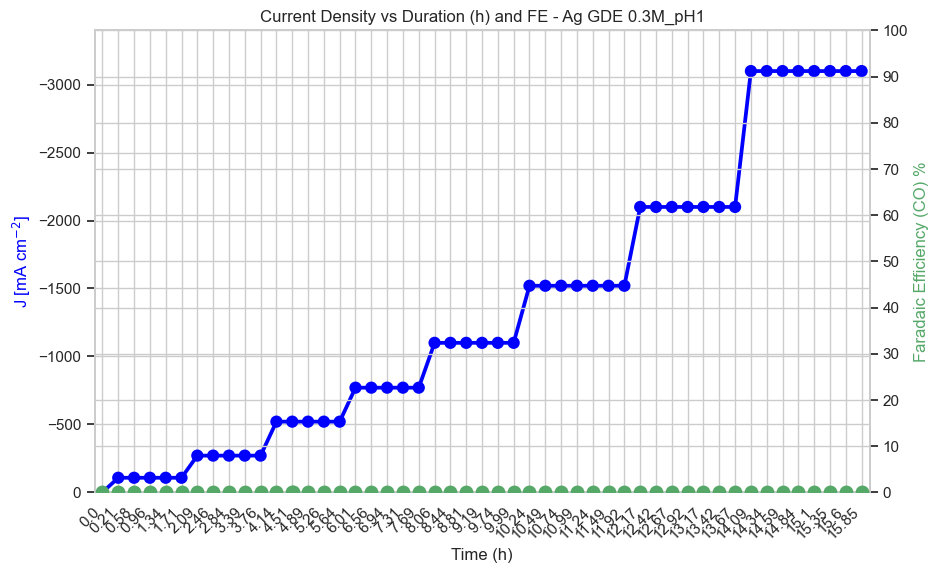

In [654]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis
sns.set(style="whitegrid")
sns.pointplot(data=Book, x='Duration / h', y='Current Density', ax=ax1, color='blue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Duration (h) and FE - Ag GDE 0.3M_pH1')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel(r'J [mA cm$^{-2}$]', color='blue')
ax1.set_ylim(0, -3400)
ax1.set_yticks(np.arange(0, -3400, -500))
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=Book, x='Duration / h',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=1, legend=False, color = "g")

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color = "g")
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))
# ax2.set_xticks(np.arange(0, 18, 1))
# ax2.set_xticklabels(np.arange(0, 18, 1))

# plt.savefig('20240531_Ag_GDE_0_3M_pH1_CD_Durat_FE_lineplot.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

## Stacked bar plot

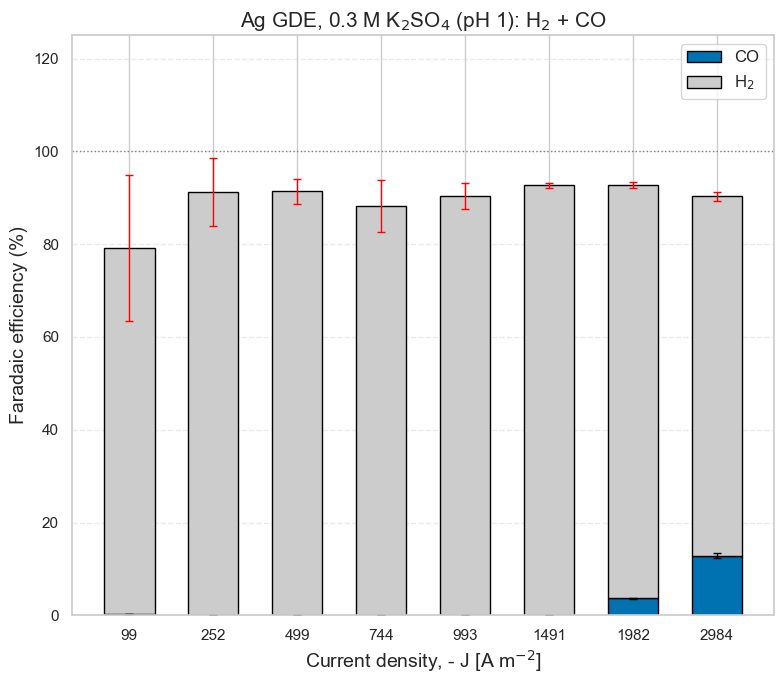

In [655]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_mean"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_mean"], w,
       bottom=summary["FE_CO_mean"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (bottom segment)
ax.errorbar(x, summary["FE_CO_mean"],
            yerr=summary["FE_CO_sem"],
            fmt="none", ecolor="black", capsize=3, lw=1)

# Error bars for H2 (top segment → must be shifted by CO)
ax.errorbar(x, summary["FE_CO_mean"] + summary["FE_H2_mean"],
            yerr=summary["FE_H2_sem"],
            fmt="none", ecolor="red", capsize=3, lw=1)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.3 M K$_2$SO$_4$ (pH 1): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_mean"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

## Median

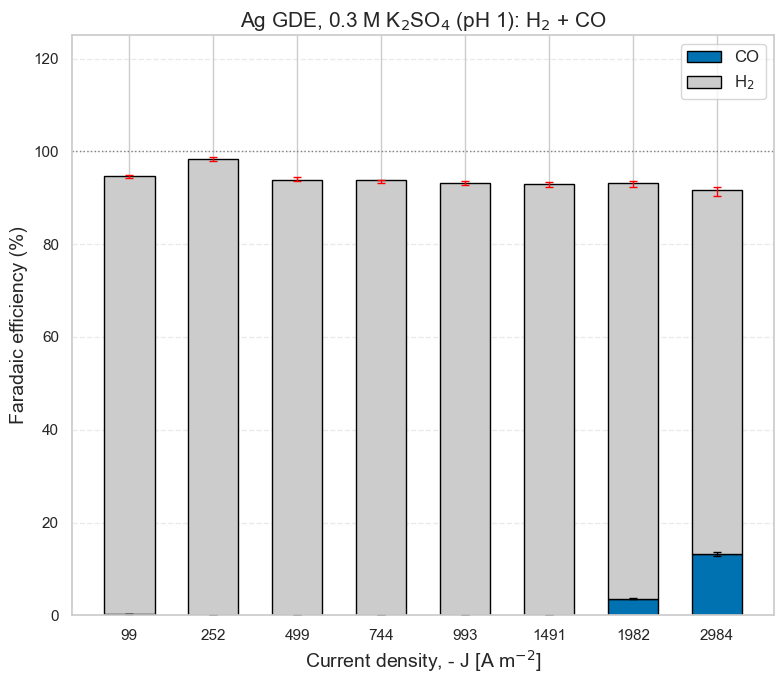

In [656]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_median"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_median"], w,
       bottom=summary["FE_CO_median"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (median + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"],
    yerr=[
        summary["FE_CO_err_low"],
        summary["FE_CO_err_high"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    lw=1
)

# Error bars for H2 (shifted by CO + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"] + summary["FE_H2_median"],
    yerr=[
        summary["FE_H2_err_low"],
        summary["FE_H2_err_high"]
    ],
    fmt="none",
    ecolor="red",
    capsize=3,
    lw=1
)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.3 M K$_2$SO$_4$ (pH 1): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_median"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
plt.savefig("FE_H2_CO_stacked_median_IQR.png", dpi=300, bbox_inches="tight")
plt.show()

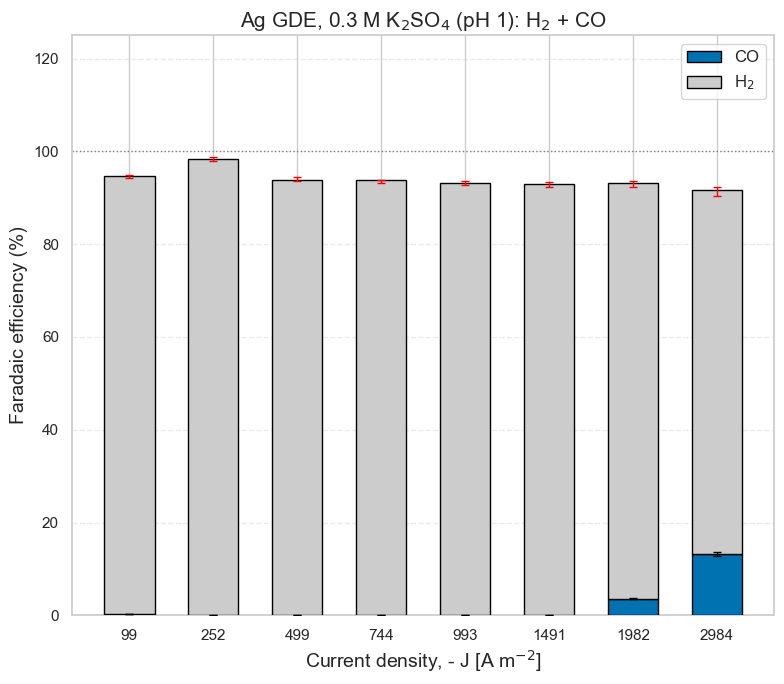

In [657]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

# okabe_ito = ['#000000', '#D55E00', '#56B4E9', '#F0E442',
             # '#0072B2', '#009E73', '#CC79A7', '#E69F00']

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))

# Widths
w_CO2 = 0.7   # wider background bar
w = 0.6       # CO + H2 foreground bars

# ---------------------------------------------------------
# CO — foreground, starts from zero
# ---------------------------------------------------------
ax.bar(
    x,
    summary["FE_CO_median"],
    w,
    color=color_CO,
    edgecolor="black",
    lw=1,
    label="CO",
    zorder=3
)

# ---------------------------------------------------------
# H2 — stacked on CO
# ---------------------------------------------------------
ax.bar(
    x,
    summary["FE_H2_median"],
    w,
    bottom=summary["FE_CO_median"],
    color=color_H2,
    edgecolor="black",
    lw=1,
    label=r"H$_2$",
    zorder=3
)

# ---------------------------------------------------------
# Error bars for CO
# ---------------------------------------------------------
ax.errorbar(
    x,
    summary["FE_CO_median"],
    yerr=[
        summary["FE_CO_err_low"],
        summary["FE_CO_err_high"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    lw=1,
    zorder=4
)

# ---------------------------------------------------------
# Error bars for H2
# ---------------------------------------------------------
ax.errorbar(
    x,
    summary["FE_CO_median"] + summary["FE_H2_median"],
    yerr=[
        summary["FE_H2_err_low"],
        summary["FE_H2_err_high"]
    ],
    fmt="none",
    ecolor="red",
    capsize=3,
    lw=1,
    zorder=4
)

# 100% reference
ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)

ax.set_title(
    r"Ag GDE, 0.3 M K$_2$SO$_4$ (pH 1): H$_2$ + CO",
    fontsize=15
)

# Make sure the limit accounts for both types of bars
max_value = max(
    summary["area_CO2_median"].max(),
    (summary["FE_CO_median"] + summary["FE_H2_median"]).max()
)

ax.set_ylim(0, max(125, max_value * 1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
plt.savefig(
    "FE_H2_CO_CO2_median_IQR.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Mean and Standard Deviation Applied Current and FE(CO)

In [658]:
standard_current_density = [
    100, 250, 500, 750,
    1000, 1500, 2000, 3000
]
summary["J (A m-2)_ps"] = summary["J (A m-2)"]
summary["J (A m-2)"] = standard_current_density #This is to have the same basis for later compare different experiments

In [659]:
Res_Book = summary.copy()

Res_Book = Res_Book.fillna(0)

Res_Book = Res_Book.rename(columns={
    # Mean
    "FE_H2_mean": "FE(H2)_mean",
    "FE_CO_mean": "FE(CO)_mean",
    "FE_total_mean": "FE(total)_mean",

    # Median
    "FE_H2_median": "FE(H2)_median",
    "FE_CO_median": "FE(CO)_median",
    "FE_total_median": "FE(total)_median",

    # Median error
    "FE_H2_q25": "FE(H2)_q25",
    "FE_H2_q75": "FE(H2)_q75",
    "FE_H2_err_low": "FE(H2)_err_low",
    "FE_H2_err_high": "FE(H2)_err_high",

    "FE_CO_q25": "FE(CO)_q25",
    "FE_CO_q75": "FE(CO)_q75",
    "FE_CO_err_low": "FE(CO)_err_low",
    "FE_CO_err_high": "FE(CO)_err_high",

    "FE_total_q25": "FE(total)_q25",
    "FE_total_q75": "FE(total)_q75",
    "FE_total_err_low": "FE(total)_err_low",
    "FE_total_err_high": "FE(total)_err_high",

    # SEM
    "FE_H2_sem": "FE(H2)_sem",
    "FE_CO_sem": "FE(CO)_sem",
    "FE_total_sem": "FE(total)_sem",

    # Standard deviation
    "FE_H2_std": "FE(H2)_std",
    "FE_CO_std": "FE(CO)_std",
    "FE_total_std": "FE(total)_std",

    # Current density
    "Current Density [A/m2]": "Current Density_mean"
})

Res_Book

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,area_CO2_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,78.892019,0.236572,94.442241,0.247735,100.397004,15.780327,0.051793,38.653749,0.126866,...,0.012232,6,0.417511,0.316435,0.013735,0.067734,0.450499,0.259031,0–2,99
1,250,91.137200,0.084336,98.346968,0.084936,98.769459,7.279985,0.003284,16.278541,0.007343,...,0.031467,5,0.450410,0.335586,0.007811,0.004362,0.450664,0.347760,2–4,252
2,500,91.348438,0.033882,93.848953,0.034391,96.303069,2.760235,0.002506,6.761168,0.006138,...,0.057509,6,0.213565,0.604644,0.000469,0.001093,0.214640,0.606412,4–6,499
3,750,88.166408,0.020900,93.858555,0.014945,93.686355,5.630737,0.004323,12.590711,0.009666,...,0.083159,5,0.596274,0.038331,0.000814,0.015758,0.576672,0.039903,6–8,744
4,1000,90.424725,0.008904,93.123797,0.008794,91.227310,2.795809,0.000969,6.848307,0.002373,...,0.106923,6,0.446375,0.385282,0.001474,0.001747,0.445875,0.383655,8–10,993
5,1500,92.609670,0.047369,92.914704,0.042575,86.744782,0.456415,0.003928,1.207562,0.010393,...,0.150701,7,0.720398,0.495712,0.001377,0.011494,0.720893,0.508124,10–12,1491
6,2000,89.004865,3.671928,89.650932,3.627057,82.440248,0.626670,0.097798,1.658012,0.258749,...,0.185843,7,1.005223,0.410290,0.093600,0.147166,0.633875,0.316690,12–14,1982
7,3000,77.462622,12.848017,78.445054,13.243103,74.886332,0.977531,0.559105,2.764874,1.581387,...,0.230364,8,1.384075,0.650109,0.413914,0.422660,0.883719,0.248529,14–16,2984


In [662]:
Res_Book
# Res_Book.to_csv('20240531_0.3M K2SO4_pH1.csv')

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,area_CO2_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,78.892019,0.236572,94.442241,0.247735,100.397004,15.780327,0.051793,38.653749,0.126866,...,0.012232,6,0.417511,0.316435,0.013735,0.067734,0.450499,0.259031,0–2,99
1,250,91.137200,0.084336,98.346968,0.084936,98.769459,7.279985,0.003284,16.278541,0.007343,...,0.031467,5,0.450410,0.335586,0.007811,0.004362,0.450664,0.347760,2–4,252
2,500,91.348438,0.033882,93.848953,0.034391,96.303069,2.760235,0.002506,6.761168,0.006138,...,0.057509,6,0.213565,0.604644,0.000469,0.001093,0.214640,0.606412,4–6,499
3,750,88.166408,0.020900,93.858555,0.014945,93.686355,5.630737,0.004323,12.590711,0.009666,...,0.083159,5,0.596274,0.038331,0.000814,0.015758,0.576672,0.039903,6–8,744
4,1000,90.424725,0.008904,93.123797,0.008794,91.227310,2.795809,0.000969,6.848307,0.002373,...,0.106923,6,0.446375,0.385282,0.001474,0.001747,0.445875,0.383655,8–10,993
5,1500,92.609670,0.047369,92.914704,0.042575,86.744782,0.456415,0.003928,1.207562,0.010393,...,0.150701,7,0.720398,0.495712,0.001377,0.011494,0.720893,0.508124,10–12,1491
6,2000,89.004865,3.671928,89.650932,3.627057,82.440248,0.626670,0.097798,1.658012,0.258749,...,0.185843,7,1.005223,0.410290,0.093600,0.147166,0.633875,0.316690,12–14,1982
7,3000,77.462622,12.848017,78.445054,13.243103,74.886332,0.977531,0.559105,2.764874,1.581387,...,0.230364,8,1.384075,0.650109,0.413914,0.422660,0.883719,0.248529,14–16,2984


## Mean and StD of FE(CO) through time

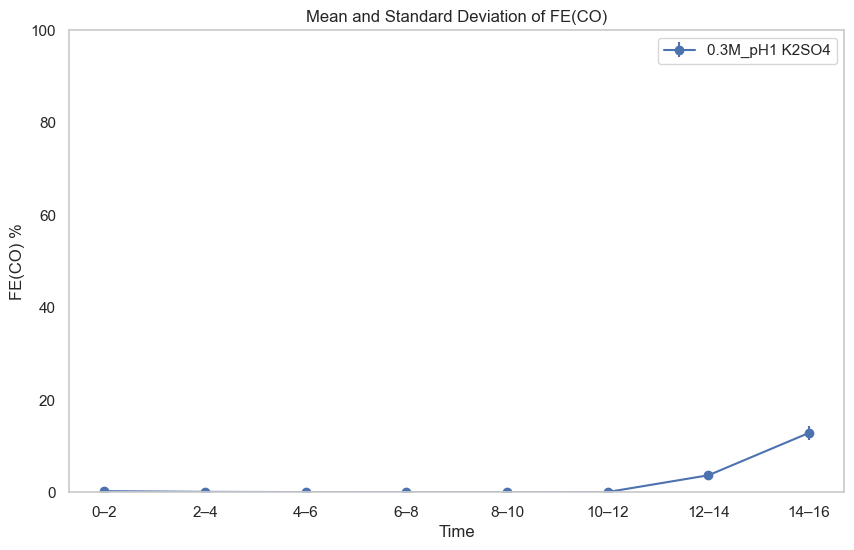

In [663]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation
ax.errorbar(Res_Book["Time Interval (h)"], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_std'], fmt='-o', label='0.3M_pH1 K2SO4')

# Formatting the plot
ax.set_xlabel('Time')
ax.set_ylabel('FE(CO) %')
ax.set_title('Mean and Standard Deviation of FE(CO)')
ax.set_ylim(0,100)
ax.legend()
ax.grid(False)

# plt.savefig('20240531_0.3M_pH1_mean_std_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

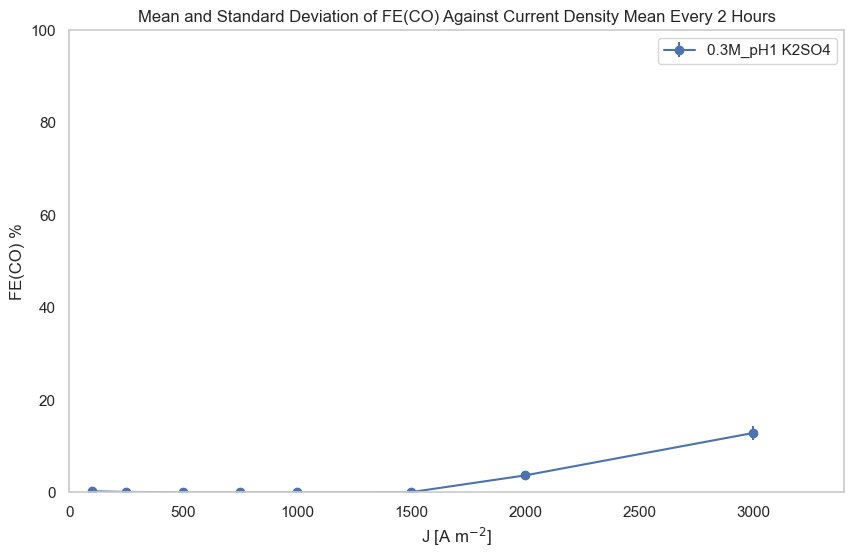

In [664]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_std'], fmt='-o', label='0.3M_pH1 K2SO4')

# Formatting the plot
ax.set_xlabel(r'J [A m$^{-2}$]')
ax.set_ylabel('FE(CO) %')
ax.set_xlim(0,3400)
ax.set_ylim(0,100)
ax.set_title('Mean and Standard Deviation of FE(CO) Against Current Density Mean Every 2 Hours')
ax.legend()
ax.grid(False)

# plt.savefig('20240531_0.3M_pH1_mean_std_FE(CO)vsCD.png', dpi=300, bbox_inches='tight')
plt.show()